# 04 —-Konačna evaluacija retrieval modela

U ovom notebook-u radimo konačnu evaluaciju izabranog modela na `test.pt` skupu.

Evaluacija sistema je predviđena za oba pravca:
- **Text → Image** — tekstualni opis → najrelevantnije slike
- **Image → Text** — slika → najrelevantniji tekstualni opisi


Evaluacija se radi na nivou clothing item-a, što znači da je rezultat tačan ako pronađeni uzorak pripada istom komadu odeće.


## 1. Učitavanje test skupa i modela

Koristimo postojeće test embeddinge iz `embeddings/test.pt` — ovaj skup nije korišćen ni u treningu ni u izboru modela (validation skup), pa daje nepristrasnu procenu.

Učitavamo i izabrani model (`embeddings/multimodal_model.pt`), sačuvan tokom treninga kao checkpoint sa najboljim validation loss-om. `MultimodalRetriever` obavija taj model i pruža jednostavan interfejs za projekciju embeddinga i retrieval.

Embeddinge ovde ne generišemo ponovo (to je urađeno unapred preko `scripts/generate_embeddings.py`) — ovaj notebook se fokusira isključivo na evaluaciju.


In [1]:
from pathlib import Path
import sys
import re
import random

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from vision_language_clothing_retrieval.retrieval.multimodal_retriever import (
    MultimodalRetriever,
)

TEST_PATH = PROJECT_ROOT / "embeddings" / "test.pt"
MODEL_PATH = PROJECT_ROOT / "embeddings" / "multimodal_model.pt"
RESULTS_DIR = PROJECT_ROOT / "embeddings" / "experiments"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cpu"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

test_data = torch.load(TEST_PATH, weights_only=True)

image_embeddings = test_data["image_embeddings"]
text_embeddings = test_data["text_embeddings"]
sample_ids = test_data["sample_ids"]

retriever = MultimodalRetriever(
    model_path=str(MODEL_PATH),
    device=DEVICE,
)

print("Broj test uzoraka:", len(sample_ids))
print("Dimenzija image embeddinga:", tuple(image_embeddings.shape))
print("Dimenzija text embeddinga:", tuple(text_embeddings.shape))


Broj test uzoraka: 4136
Dimenzija image embeddinga: (4136, 512)
Dimenzija text embeddinga: (4136, 768)


## 2. Projektovanje embeddinga

ResNet10 i DistilBERT proizvode embeddinge različitih dimenzija (512 za slike, 768 za tekst), pa se ne mogu direktno porediti. Projekcioni slojevi modela preslikavaju oba u zajednički 256-dimenzionalni prostor gde su direktno uporedivi.

Nakon projekcije, embeddinge normalizujemo (L2 norma) kako bi skalarni proizvod odgovarao cosine similarity vrednosti.


In [2]:
with torch.no_grad():
    projected_images, projected_texts = retriever.project_embeddings(
        image_embeddings,
        text_embeddings,
    )

projected_images = F.normalize(projected_images, p=2, dim=1)
projected_texts = F.normalize(projected_texts, p=2, dim=1)

print("Projektovani image embeddingi:", tuple(projected_images.shape))
print("Projektovani text embeddingi:", tuple(projected_texts.shape))


Projektovani image embeddingi: (4136, 256)
Projektovani text embeddingi: (4136, 256)


## 3. Matrica sličnosti

Za svaki tekstualni upit računamo cosine similarity sa svim slikama u test skupu, dobijajući matricu oblika `(broj_tekstova, broj_slika)`.

Redovi predstavljaju tekstualne upite, kolone slike — element `[i, j]` je sličnost i-tog teksta sa j-tom slikom. Ova ista matrica se kasnije koristi u oba smera: direktno za Text → Image, i transponovana (`.T`) za Image → Text, bez ponovnog računanja.



In [3]:
with torch.no_grad():
    similarity_matrix = projected_texts @ projected_images.T

print("Oblik matrice sličnosti:", tuple(similarity_matrix.shape))
print(
    "Raspon cosine similarity vrednosti:",
    round(float(similarity_matrix.min()), 4),
    "do",
    round(float(similarity_matrix.max()), 4),
)


Oblik matrice sličnosti: (4136, 4136)
Raspon cosine similarity vrednosti: -0.6102 do 0.7621


## 4. Identifikacija clothing item-a

Svaki artikal u DeepFashion-MultiModal datasetu ima više fotografija (front/back/side/additional), svaka sa svojim `sample_id` (npr. `WOMEN-Dresses-id_00007179-04_1_front`). Zato evaluacija na nivou pojedinačne slike/teksta ne bi bila fer — ispravnije je proveriti da li je pronađen **bilo koji** uzorak istog artikla, ne samo tačno taj jedan.

Iz `sample_id` regexom izdvajamo ID artikla (deo posle `-id_`), koji dalje koristimo kao osnovu za poređenje "isti item / različit item" kroz sve metrike u nastavku.


In [4]:
def get_item_id(sample_id):
    sample_id = str(sample_id)
    match = re.search(r"-id_([^ -]+?)(?=-\d|$)", sample_id)

    if match:
        return match.group(1)

    if "-id_" in sample_id:
        return sample_id.split("-id_", 1)[1].split("-", 1)[0]

    return sample_id


item_ids = np.array([get_item_id(sample_id) for sample_id in sample_ids])

print("Primeri sample_id → item_id:")
for sample_id, item_id in zip(sample_ids[:5], item_ids[:5]):
    print(sample_id, "→", item_id)


Primeri sample_id → item_id:
WOMEN-Dresses-id_00007179-04_1_front → 00007179
WOMEN-Dresses-id_00007179-04_2_side → 00007179
WOMEN-Dresses-id_00007179-04_3_back → 00007179
WOMEN-Dresses-id_00007179-05_1_front → 00007179
WOMEN-Dresses-id_00007179-05_2_side → 00007179


## 5. Retrieval metrike za oba pravca

Za oba pravca računamo Recall@1, Recall@5, Recall@10, MRR i Mean Rank.

Za svaki upit pronalazimo rang najboljeg kandidata koji pripada istom clothing item-u:

- kod **Text → Image**, tekst je upit, a rang se traži među slikama (najbolja slika istog artikla),
- kod **Image → Text**, slika je upit, a rang se traži među tekstovima (najbolji opis istog artikla).


In [6]:
def evaluate_direction(similarities, query_item_ids, candidate_item_ids):
    top_k = min(10, similarities.shape[1])

    _, top_indices = torch.topk(
        similarities,
        k=top_k,
        dim=1,
    )

    ranks = []
    recall_hits = {1: 0, 5: 0, 10: 0}

    for query_index in range(similarities.shape[0]):
        query_item = query_item_ids[query_index]

        relevant_mask = candidate_item_ids == query_item
        relevant_scores = similarities[query_index][relevant_mask]

        best_relevant_score = relevant_scores.max()

        rank = int(
            (similarities[query_index] > best_relevant_score).sum().item()
        ) + 1

        ranks.append(rank)

        retrieved_items = candidate_item_ids[
            top_indices[query_index].cpu().numpy()
        ]

        for k in (1, 5, 10):
            if query_item in retrieved_items[:min(k, top_k)]:
                recall_hits[k] += 1

    ranks = np.array(ranks, dtype=np.float64)
    total = len(ranks)

    return {
        "recall@1": recall_hits[1] / total,
        "recall@5": recall_hits[5] / total,
        "recall@10": recall_hits[10] / total,
        "mrr": float(np.mean(1.0 / ranks)),
        "mean_rank": float(np.mean(ranks)),
        "ranks": ranks,
    }


text_to_image_results = evaluate_direction(
    similarity_matrix,
    item_ids,
    item_ids,
)

image_to_text_results = evaluate_direction(
    similarity_matrix.T,
    item_ids,
    item_ids,
)

for direction, results in [
    ("Text → Image", text_to_image_results),
    ("Image → Text", image_to_text_results),
]:
    print("\n" + direction)
    for name in ("recall@1", "recall@5", "recall@10", "mrr", "mean_rank"):
        print(f"{name}: {results[name]:.4f}")



Text → Image
recall@1: 0.0334
recall@5: 0.1081
recall@10: 0.1736
mrr: 0.0828
mean_rank: 198.3859

Image → Text
recall@1: 0.0193
recall@5: 0.0786
recall@10: 0.1342
mrr: 0.0611
mean_rank: 259.4076


## 6. Konačna tabela rezultata

Sabiramo sve izračunate metrike (Recall@1, Recall@5, Recall@10, MRR, Mean Rank) za oba smera u jednu preglednu tabelu — polazna tačka za sve grafikone i zaključke koji slede.


In [7]:
final_metrics = pd.DataFrame({
    "Metrika": [
        "Recall@1",
        "Recall@5",
        "Recall@10",
        "MRR",
        "Mean Rank",
    ],
    "Text → Image": [
        text_to_image_results["recall@1"],
        text_to_image_results["recall@5"],
        text_to_image_results["recall@10"],
        text_to_image_results["mrr"],
        text_to_image_results["mean_rank"],
    ],
    "Image → Text": [
        image_to_text_results["recall@1"],
        image_to_text_results["recall@5"],
        image_to_text_results["recall@10"],
        image_to_text_results["mrr"],
        image_to_text_results["mean_rank"],
    ],
})

final_metrics


,Metrika,Text → Image,Image → Text
0,Recall@1,0.033366,0.019342
1,Recall@5,0.108075,0.078578
2,Recall@10,0.173598,0.134188
3,MRR,0.082824,0.061145
4,Mean Rank,198.385880,259.407640


## 7. Vizuelno poređenje metrika

Kod Recall-a i MRR-a veća vrednost je bolja, dok je kod Mean Rank-a manja vrednost bolja — obrnuta logika, pa ih namerno prikazujemo na odvojenim panelima. Recall@1/5/10 i MRR su svi na skali 0-1 i direktno uporedivi, dok je Mean Rank na skali broja uzoraka (stotine) — da ostanu na istom grafiku, manje metrike bi postale nevidljive.


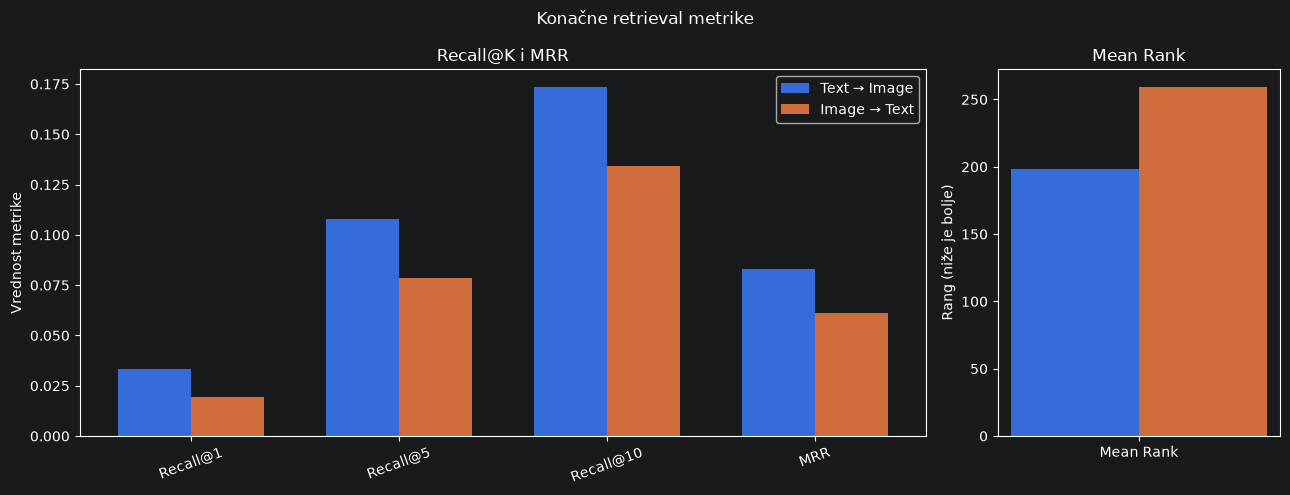

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [3, 1]})

rate_metrics = final_metrics[final_metrics["Metrika"] != "Mean Rank"]
x1 = np.arange(len(rate_metrics))
width = 0.35

ax1.bar(x1 - width / 2, rate_metrics["Text → Image"], width, label="Text → Image")
ax1.bar(x1 + width / 2, rate_metrics["Image → Text"], width, label="Image → Text")

ax1.set_xticks(x1)
ax1.set_xticklabels(rate_metrics["Metrika"], rotation=20)
ax1.set_ylabel("Vrednost metrike")
ax1.set_title("Recall@K i MRR")
ax1.legend()

rank_metric = final_metrics[final_metrics["Metrika"] == "Mean Rank"]
x2 = np.arange(1)

ax2.bar(x2 - width / 2, rank_metric["Text → Image"], width, label="Text → Image")
ax2.bar(x2 + width / 2, rank_metric["Image → Text"], width, label="Image → Text")

ax2.set_xticks(x2)
ax2.set_xticklabels(["Mean Rank"])
ax2.set_ylabel("Rang (niže je bolje)")
ax2.set_title("Mean Rank")

plt.suptitle("Konačne retrieval metrike")
plt.tight_layout()
plt.show()


## 8. Distribucija rangova

Prikazujemo rang prvog relevantnog rezultata za svaki upit — što je masa histograma bliža nuli, model uspešnije rangira tačne rezultate na vrh liste.

Y-osa je na log skali, jer je razlika između najčešćeg ishoda (nizak rang) i retkih velikih rangova (rep distribucije) prevelika za linearnu skalu — na log skali se rep jasnije vidi. Koristimo konturne (`step`) histograme umesto punih, da se boje oba smera ne bi mešale tamo gde se preklapaju.


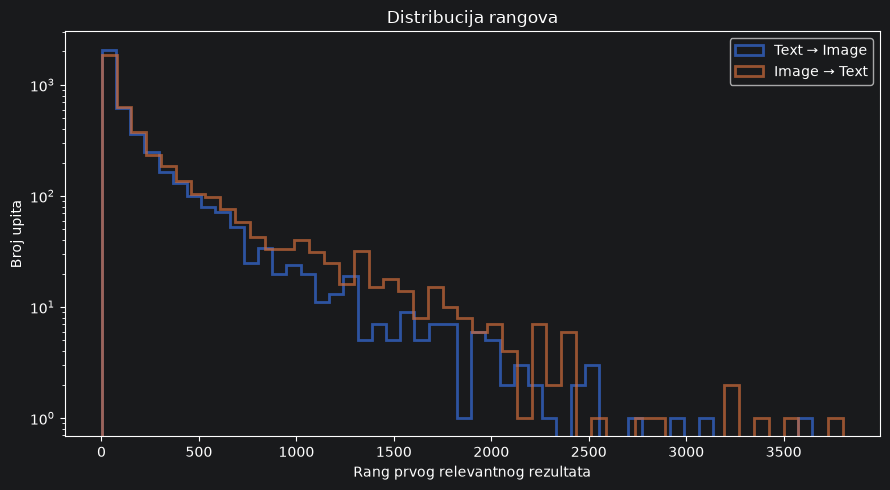

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    text_to_image_results["ranks"],
    bins=50,
    histtype="step",
    alpha=0.7,
    linewidth=2,
    label="Text → Image",
)

ax.hist(
    image_to_text_results["ranks"],
    bins=50,
    histtype="step",
    alpha=0.7,
    linewidth=2,
    label="Image → Text",
)

ax.set_yscale("log")
ax.set_xlabel("Rang prvog relevantnog rezultata")
ax.set_ylabel("Broj upita")
ax.set_title("Distribucija rangova")
ax.legend()

plt.tight_layout()
plt.show()


## 9. ROC kriva i AUC

ROC/AUC je dodatna, pomoćna analiza — posmatra retrieval kao binarnu klasifikaciju ("da li ovaj par pripada istom clothing item-u"), a ne kao rangiranje. Za svaki upit uzimamo sve pozitivne parove (isti artikal) i slučajan uzorak negativnih parova (različit artikal), i merimo koliko dobro similarity score razdvaja te dve grupe.

Ove metrike ne zamenjuju retrieval metrike iz sekcije 5 — služe kao dodatna perspektiva na ponašanje modela.


In [14]:
def build_pairs(similarities, item_ids, negative_count=100000):
    positive_scores = []
    negative_scores = []


    rng = np.random.default_rng(SEED)
    n = similarities.shape[0]

    for query_index in range(n):
        same_item = item_ids == item_ids[query_index]

        positive_scores.extend(
            similarities[query_index][same_item].cpu().numpy()
        )

        negative_indices = np.where(~same_item)[0]

        if len(negative_indices) > 0:
            count = min(
                len(negative_indices),
                max(1, negative_count // n),
            )

            selected = rng.choice(
                negative_indices,
                size=count,
                replace=False,
            )

            negative_scores.extend(
                similarities[query_index][selected].cpu().numpy()
            )

    scores = np.concatenate([
        np.asarray(positive_scores),
        np.asarray(negative_scores),
    ])

    labels = np.concatenate([
        np.ones(len(positive_scores), dtype=np.int8),
        np.zeros(len(negative_scores), dtype=np.int8),
    ])

    return scores, labels

t2i_scores, t2i_labels = build_pairs(similarity_matrix, item_ids)
i2t_scores, i2t_labels = build_pairs(similarity_matrix.T, item_ids)


In [15]:
def calculate_roc(scores, labels):
    order = np.argsort(scores)[::-1]

    sorted_scores = scores[order]
    sorted_labels = labels[order]

    true_positives = np.cumsum(sorted_labels == 1)
    false_positives = np.cumsum(sorted_labels == 0)

    total_positives = true_positives[-1]
    total_negatives = false_positives[-1]

    unique_positions = np.r_[
        np.where(np.diff(sorted_scores) != 0)[0],
        len(sorted_scores) - 1,
    ]

    tpr = true_positives[unique_positions] / total_positives
    fpr = false_positives[unique_positions] / total_negatives
    thresholds = sorted_scores[unique_positions]

    fpr = np.r_[0.0, fpr]
    tpr = np.r_[0.0, tpr]
    thresholds = np.r_[thresholds[0] + 1e-12, thresholds]

    auc_value = np.trapezoid(tpr, fpr)

    return fpr, tpr, thresholds, float(auc_value)


t2i_fpr, t2i_tpr, t2i_thresholds, t2i_auc = calculate_roc(
    t2i_scores,
    t2i_labels,
)

i2t_fpr, i2t_tpr, i2t_thresholds, i2t_auc = calculate_roc(
    i2t_scores,
    i2t_labels,
)

print("ROC AUC — Text → Image:", round(t2i_auc, 4))
print("ROC AUC — Image → Text:", round(i2t_auc, 4))


ROC AUC — Text → Image: 0.7407
ROC AUC — Image → Text: 0.7409


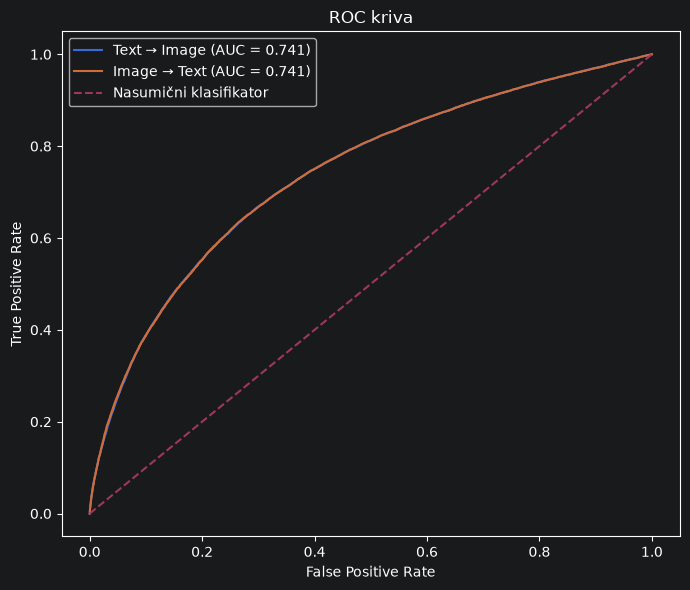

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    t2i_fpr,
    t2i_tpr,
    label=f"Text → Image (AUC = {t2i_auc:.3f})",
)

ax.plot(
    i2t_fpr,
    i2t_tpr,
    label=f"Image → Text (AUC = {i2t_auc:.3f})",
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Nasumični klasifikator",
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC kriva")
ax.legend()

plt.tight_layout()
plt.show()


## 10. Matrica konfuzije

Matrica konfuzije je pomoćna analiza. Prag biramo pomoću Youden-ovog kriterijuma na osnovu ROC krive.

**Zašto su brojevi veći od broja test uzoraka:** matrica ne broji slike ili tekstove, već **parove** (upit-kandidat kombinacije) konstruisane u `build_pairs()`. Svaki od 4136 test upita generiše više parova — sve pozitivne (isti artikal) i uzorak negativnih (različit artikal) — pa ukupan broj parova (137.564) prirodno premašuje broj test uzoraka.


In [17]:
def select_threshold(scores, labels):
    fpr, tpr, thresholds, _ = calculate_roc(scores, labels)
    best_index = np.argmax(tpr - fpr)
    return float(thresholds[best_index])


def confusion_matrix_values(scores, labels, threshold):
    predictions = scores >= threshold

    tp = int(np.sum(predictions & (labels == 1)))
    fp = int(np.sum(predictions & (labels == 0)))
    tn = int(np.sum(~predictions & (labels == 0)))
    fn = int(np.sum(~predictions & (labels == 1)))

    return np.array([
        [tn, fp],
        [fn, tp],
    ])


t2i_threshold = select_threshold(t2i_scores, t2i_labels)
i2t_threshold = select_threshold(i2t_scores, i2t_labels)

t2i_cm = confusion_matrix_values(
    t2i_scores,
    t2i_labels,
    t2i_threshold,
)
i2t_cm = confusion_matrix_values(
    i2t_scores,
    i2t_labels,
    i2t_threshold
)

print("Prag Text → Image:", round(t2i_threshold, 4))
print("Prag Image → Text:", round(i2t_threshold, 4))


Prag Text → Image: 0.3024
Prag Image → Text: 0.3022


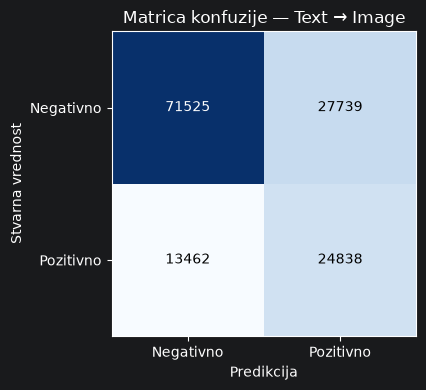

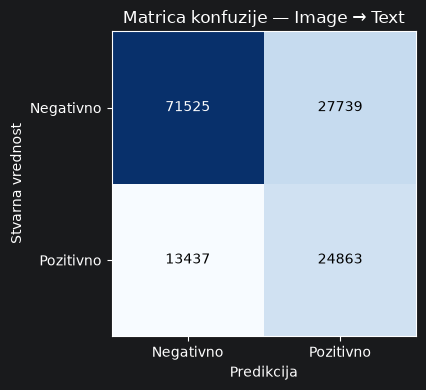

In [28]:
def plot_confusion_matrix(matrix, title):
    fig, ax = plt.subplots(figsize=(5, 4))

    im = ax.imshow(matrix, cmap="Blues")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Negativno", "Pozitivno"])
    ax.set_yticklabels(["Negativno", "Pozitivno"])

    ax.set_xlabel("Predikcija")
    ax.set_ylabel("Stvarna vrednost")
    ax.set_title(title)

    threshold = matrix.max() / 2
    for row in range(2):
        for column in range(2):
            value = matrix[row, column]
            color = "white" if value > threshold else "black"
            ax.text(
                column,
                row,
                str(value),
                ha="center",
                va="center",
                color=color,
            )

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(
    t2i_cm,
    "Matrica konfuzije — Text → Image",
)

plot_confusion_matrix(
    i2t_cm,
    "Matrica konfuzije — Image → Text",
)


## 11. Distribucija cosine similarity vrednosti

Upoređujemo similarity vrednosti pozitivnih i negativnih text-image parova.

Ako model dobro odvaja odgovarajuće parove, histogram pozitivnih vrednosti treba da bude pomeren udesno (viši similarity) u odnosu na negativne, sa što manje preklapanja između njih — veliko preklapanje znači da model teško razlikuje "sličan po slučaju" od "stvarno isti artikal".


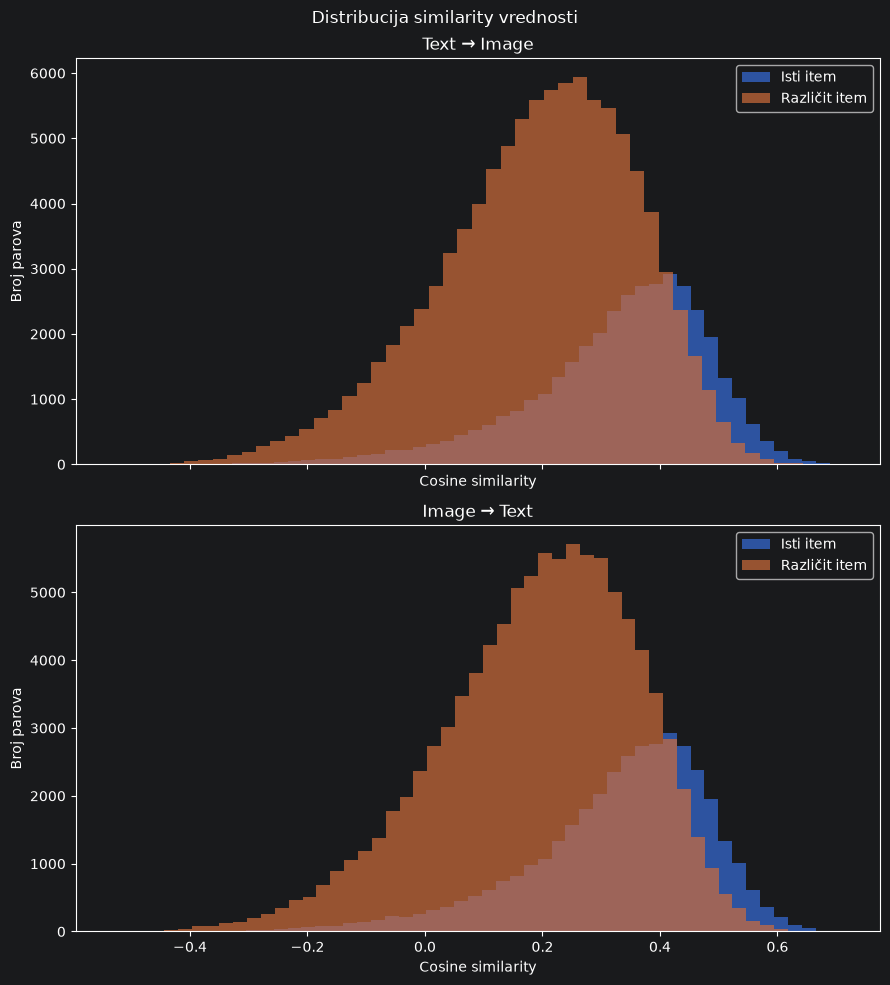

In [35]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 10), sharex=True)

ax1.hist(t2i_scores[t2i_labels == 1], bins=50, alpha=0.7, label="Isti item")
ax1.hist(t2i_scores[t2i_labels == 0], bins=50, alpha=0.7, label="Različit item")
ax1.set_xlabel("Cosine similarity")
ax1.set_ylabel("Broj parova")
ax1.set_title("Text → Image")
ax1.legend()

ax2.hist(i2t_scores[i2t_labels == 1], bins=50, alpha=0.7, label="Isti item")
ax2.hist(i2t_scores[i2t_labels == 0], bins=50, alpha=0.7, label="Različit item")
ax2.set_xlabel("Cosine similarity")
ax2.set_ylabel("Broj parova")
ax2.set_title("Image → Text")
ax2.legend()

plt.suptitle("Distribucija similarity vrednosti")
plt.tight_layout()
plt.show()


## 12. Primeri retrieval rezultata

Konkretni primeri upita i njihovih top-5 rezultata, za oba smera, uz oznaku da li je pronađeni uzorak zaista isti artikal kao upit.

Pošto `test.pt` sadrži embeddinge i `sample_id` vrednosti, rezultate prikazujemo preko identifikatora i similarity skora.


In [30]:
def show_examples(
    similarities,
    sample_ids,
    item_ids,
    direction,
    number_of_examples=5,
    top_k=5,
):
    for query_index in range(min(number_of_examples, len(sample_ids))):
        scores, indices = torch.topk(
            similarities[query_index],
            k=top_k,
        )

        print(f"\nUpit — {direction}: {sample_ids[query_index]}")
        print("Item ID:", item_ids[query_index])
        print("Rezultati:")

        for rank, (index, score) in enumerate(
            zip(indices.tolist(), scores.tolist()),
            start=1,
        ):
            correct = item_ids[index] == item_ids[query_index]

            print(
                f"{rank}. {sample_ids[index]} | "
                f"score={score:.4f} | "
                f"isti item={correct}"
            )

show_examples(
    similarity_matrix,
    sample_ids,
    item_ids,
    "Text → Image",
)

show_examples(
    similarity_matrix.T,
    sample_ids,
    item_ids,
    "Image → Text",
)



Upit — Text → Image: WOMEN-Dresses-id_00007179-04_1_front
Item ID: 00007179
Rezultati:
1. WOMEN-Dresses-id_00001630-02_7_additional | score=0.6027 | isti item=False
2. WOMEN-Dresses-id_00001630-02_1_front | score=0.6008 | isti item=False
3. WOMEN-Rompers_Jumpsuits-id_00004725-06_7_additional | score=0.5987 | isti item=False
4. WOMEN-Rompers_Jumpsuits-id_00004725-04_1_front | score=0.5861 | isti item=False
5. WOMEN-Dresses-id_00001630-02_2_side | score=0.5859 | isti item=False

Upit — Text → Image: WOMEN-Dresses-id_00007179-04_2_side
Item ID: 00007179
Rezultati:
1. WOMEN-Rompers_Jumpsuits-id_00004725-06_7_additional | score=0.5806 | isti item=False
2. WOMEN-Rompers_Jumpsuits-id_00004725-04_1_front | score=0.5789 | isti item=False
3. WOMEN-Dresses-id_00006875-02_1_front | score=0.5725 | isti item=False
4. WOMEN-Skirts-id_00007788-07_2_side | score=0.5645 | isti item=False
5. WOMEN-Dresses-id_00001630-02_2_side | score=0.5587 | isti item=False

Upit — Text → Image: WOMEN-Dresses-id_00007

## 13. Čuvanje rezultata

Sve izračunate metrike (oba smera, uključujući ROC AUC) čuvamo u CSV fajlu radi lakšeg poređenja sa budućim eksperimentima (npr. druga arhitektura ili drugi broj epoha), bez potrebe da se cela evaluacija ponovo pokreće.


In [31]:
summary_results = pd.DataFrame([{
    "model": "Baseline",
    "text_to_image_recall_at_1": text_to_image_results["recall@1"],
    "text_to_image_recall_at_5": text_to_image_results["recall@5"],
    "text_to_image_recall_at_10": text_to_image_results["recall@10"],
    "text_to_image_mrr": text_to_image_results["mrr"],
    "text_to_image_mean_rank": text_to_image_results["mean_rank"],
    "image_to_text_recall_at_1": image_to_text_results["recall@1"],
    "image_to_text_recall_at_5": image_to_text_results["recall@5"],
    "image_to_text_recall_at_10": image_to_text_results["recall@10"],
    "image_to_text_mrr": image_to_text_results["mrr"],
    "image_to_text_mean_rank": image_to_text_results["mean_rank"],
    "text_to_image_roc_auc": t2i_auc,
    "image_to_text_roc_auc": i2t_auc,
}])

summary_results.to_csv(
    RESULTS_DIR / "final_test_results.csv",
    index=False,
)

summary_results


,model,text_to_image_recall_at_1,text_to_image_recall_at_5,text_to_image_recall_at_10,text_to_image_mrr,text_to_image_mean_rank,image_to_text_recall_at_1,image_to_text_recall_at_5,image_to_text_recall_at_10,image_to_text_mrr,image_to_text_mean_rank,text_to_image_roc_auc,image_to_text_roc_auc
0,Baseline,0.033366,0.108075,0.173598,0.082824,198.38588,0.019342,0.078578,0.134188,0.061145,259.40764,0.740746,0.74093


## Zaključak

Konačna evaluacija na test skupu obuhvata oba pravca retrieval sistema.

Glavne metrike su Recall@1, Recall@5, Recall@10, MRR i Mean Rank.

ROC/AUC, matrice konfuzije, distribucije similarity vrednosti i primeri retrieval rezultata služe kao dodatne analize ponašanja modela.
